# CPI – Rural, Urban and Combined: Data Analysis

**Source:** Uploaded CPI workbook, *CPI - Rural, Urban, Combined (All India)*, base **2012 = 100**.

### What this notebook does
Instead of only listing the highest and lowest values, this analysis looks at:
- long-term CPI trends from 2013–2025
- rural vs urban inflation differences
- inflation volatility and extreme months
- food vs non-food price movements
- which commodity groups show persistent inflation pressure
- changes in rural–urban price gaps
- annual averages and year-on-year comparisons
- the latest available month (December 2025)
- data-driven story angle for a journalism assignment

In [7]:
!pip install matplotlib


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Import libraries and inspect the CPI data

This code imports Pandas, NumPy and Matplotlib, which we will use to work with the CPI data and create charts.

It then opens the CPI Excel file and looks at the data without assuming the first row is the heading. This helps us see how the Excel sheet is arranged.

Finally, it shows the size of the dataset and the first 10 rows so we can understand the data before cleaning and analysing it.

**Pandas** → helps us read, organise and analyse data in tables, like an Excel spreadsheet.

**NumPy** → helps us do mathematical and numerical calculations with the data. For example, averages, percentages and other calculations.

**Matplotlib** → helps us turn the data into charts and graphs. For example, we can use it to plot how CPI and inflation changed over the years.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

FILE = "CPI - Rural, Urban, Combined.xlsx"

raw = pd.read_excel(FILE, header=None)

print("Raw shape:", raw.shape)

display(raw.head(10))

Raw shape: (7978, 10)


,0,1,2,3,4,5,6,7,8,9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,"CPI - Rural, Urban, Combined (All India)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Base : 2012 = 100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Month,Commodity Description,Provisional / Final,Rural,NaN,Urban,NaN,Combined,NaN
6,NaN,NaN,NaN,NaN,Index,Inflation (%),Index,Inflation (%),Index,Inflation (%)
7,NaN,DEC-2025,A) General Index,Provisional,199.90,0.76,195.90,2.03,198,1.33
8,NaN,DEC-2025,A.1) Food and beverages,Provisional,199.20,-2.31,207.20,-1.05,202.10,-1.85
9,NaN,DEC-2025,A.1.1) Cereals and products,Provisional,197.20,-0.85,197.70,0.61,197.40,-0.35


### Clean and prepare the CPI data

This code cleans the raw CPI dataset so it is ready for analysis. It removes the extra rows at the top of the Excel file and keeps only the rows containing monthly CPI data. The columns are also given clear names to make them easier to use.

It then converts the month into a proper date format and changes the CPI and inflation values into numbers. Finally, it removes extra spaces from the text columns and shows the number of rows, the date range and the first few rows of the cleaned data.

In [3]:
# Remove the extra rows at the top
data = raw.iloc[7:].copy()

# Keep only rows that contain a month like Jan-2013
data = data[data[1].astype(str).str.match(r"^[A-Z]{3}-\d{4}$")]

# Give the columns simple names
data.columns = [
    "Unused", "Month", "Commodity", "Status",
    "Rural Index", "Rural Inflation",
    "Urban Index", "Urban Inflation",
    "Combined Index", "Combined Inflation"
]

# Convert Month into a date
data["Date"] = pd.to_datetime(data["Month"], format="%b-%Y")

# Convert CPI values into numbers
cols = ["Rural Index", "Rural Inflation",
        "Urban Index", "Urban Inflation",
        "Combined Index", "Combined Inflation"]

data[cols] = data[cols].apply(pd.to_numeric, errors="coerce")

# Clean text
data["Commodity"] = data["Commodity"].str.strip()
data["Status"] = data["Status"].str.strip()

print("Rows:", len(data))
print("Date range:", data["Date"].min(), "to", data["Date"].max())

display(data.head())

Rows: 7969
Date range: 2013-01-01 00:00:00 to 2025-12-01 00:00:00


,Unused,Month,Commodity,Status,Rural Index,Rural Inflation,Urban Index,Urban Inflation,Combined Index,Combined Inflation,Date
7,NaN,DEC-2025,A) General Index,Provisional,199.90,0.76,195.90,2.03,198.00,1.33,2025-12-01
8,NaN,DEC-2025,A.1) Food and beverages,Provisional,199.20,-2.31,207.20,-1.05,202.10,-1.85,2025-12-01
9,NaN,DEC-2025,A.1.1) Cereals and products,Provisional,197.20,-0.85,197.70,0.61,197.40,-0.35,2025-12-01
10,NaN,DEC-2025,A.1.2) Meat and fish,Provisional,229.70,4.84,241.70,5.68,233.90,5.12,2025-12-01
11,NaN,DEC-2025,A.1.3) Egg,Provisional,220.50,5.10,224.90,4.22,222.20,4.76,2025-12-01


## 2. Data-quality checks

These checks help prevent misleading conclusions:
1. missing values
2. duplicate observations
3. provisional vs final records
4. number of months covered


In [4]:
print("Missing values:")
display(data[cols].isna().sum().to_frame("Missing"))

print("\nStatus counts:")
display(data["Status"].value_counts().to_frame("Rows"))

print("\nPotential duplicate keys before final/provisional filtering:")
display(
    data.groupby(["Date", "Commodity"]).size()
        .value_counts()
        .sort_index()
        .rename("Number of date-commodity pairs")
        .to_frame()
)

print("\nDate coverage:", data["Date"].nunique(), "months")


Missing values:


,Missing
Rural Index,287
Rural Inflation,611
Urban Index,0
Urban Inflation,336
Combined Index,0
Combined Inflation,336



Status counts:


,Rows
Status,
Final,4339
Provisional,3630



Potential duplicate keys before final/provisional filtering:


,Number of date-commodity pairs
1,765
2,3602



Date coverage: 156 months


## 3. Remove provisional/final duplication

For each **month + commodity**, use the Final record when it exists. If a month has only a Provisional record, retain it.

This is important because otherwise a simple average, ranking or volatility calculation could count the same month twice.


In [5]:
data["status_priority"] = data["Status"].map({"Final": 1, "Provisional": 0}).fillna(0)

clean = (
    data.sort_values(["Date", "Commodity", "status_priority"])
        .drop_duplicates(["Date", "Commodity"], keep="last")
        .drop(columns="status_priority")
        .sort_values(["Date", "Commodity"])
        .reset_index(drop=True)
)

print("Rows after removing Final/Provisional duplication:", len(clean))
print("Unique months:", clean["Date"].nunique())
print("Unique commodities:", clean["Commodity"].nunique())

display(clean.head(15))


Rows after removing Final/Provisional duplication: 4367
Unique months: 156
Unique commodities: 28


,Unused,Month,Commodity,Status,Rural Index,Rural Inflation,Urban Index,Urban Inflation,Combined Index,Combined Inflation,Date
0,NaN,JAN-2013,A) General Index,Final,105.10,NaN,104.00,NaN,104.60,NaN,2013-01-01
1,NaN,JAN-2013,A.1) Food and beverages,Final,105.50,NaN,105.90,NaN,105.60,NaN,2013-01-01
2,NaN,JAN-2013,A.1.1) Cereals and products,Final,107.50,NaN,110.50,NaN,108.40,NaN,2013-01-01
3,NaN,JAN-2013,A.1.10) Spices,Final,103.10,NaN,101.80,NaN,102.70,NaN,2013-01-01
4,NaN,JAN-2013,A.1.11) Non-alcoholic beverages,Final,104.80,NaN,105.10,NaN,104.90,NaN,2013-01-01
5,NaN,JAN-2013,"A.1.12) Prepared meals, snacks, sweets etc.",Final,106.70,NaN,107.90,NaN,107.30,NaN,2013-01-01
6,NaN,JAN-2013,A.1.2) Meat and fish,Final,106.30,NaN,109.10,NaN,107.30,NaN,2013-01-01
7,NaN,JAN-2013,A.1.3) Egg,Final,108.10,NaN,113.00,NaN,110.00,NaN,2013-01-01
8,NaN,JAN-2013,A.1.4) Milk and products,Final,104.90,NaN,103.60,NaN,104.40,NaN,2013-01-01
9,NaN,JAN-2013,A.1.5) Oils and fats,Final,106.10,NaN,103.40,NaN,105.10,NaN,2013-01-01


In [9]:
## 4. Build a General Index time series

The **General Index** is the overall CPI number. It combines different categories of goods and services to show how the overall price level has changed.

We look at the General Index to understand **how prices have changed over the entire period from 2013 to 2025**.

The CPI uses **2012 = 100** as its base year. This helps us track the long-term rise in prices.

For example:

- **100** → price level is at the 2012 base
- **120** → prices are about 20% higher than the 2012 base
- **150** → prices are about 50% higher than the 2012 base

The **inflation (%)** column tells us how much prices changed compared with the same month of the previous year.

For example, if inflation is **6%**, prices are about 6% higher than they were in the same month last year.

**In simple terms:**

**CPI Index** → shows how the overall price level has changed over the long term.

**Inflation (%)** → shows how quickly prices are changing from year to year.

We need this analysis to understand both the **long-term rise in prices** and the **yearly changes in inflation**.

SyntaxError: invalid character '→' (U+2192) (4101267467.py, line 11)

In [10]:
general = (
    clean[clean["Commodity"].eq("A) General Index")]
    .sort_values("Date")
    .copy()
)

display(general[[
    "Date", "Rural Index", "Urban Index", "Combined Index",
    "Rural Inflation", "Urban Inflation", "Combined Inflation"
]].tail(12))


,Date,Rural Index,Urban Index,Combined Index,Rural Inflation,Urban Inflation,Combined Inflation
4031,2025-01-01,195.90,190.60,193.40,4.59,3.87,4.26
4059,2025-02-01,194.50,190.10,192.50,3.79,3.32,3.61
4087,2025-03-01,193.90,189.90,192.00,3.25,3.43,3.34
4115,2025-04-01,194.00,190.90,192.60,2.92,3.36,3.16
4143,2025-05-01,194.30,191.50,193.00,2.59,3.12,2.82
4171,2025-06-01,195.50,192.60,194.20,1.72,2.56,2.10
4199,2025-07-01,197.60,194.30,196.10,1.18,2.10,1.61
4227,2025-08-01,198.70,195.00,197.00,1.69,2.47,2.07
4255,2025-09-01,198.80,194.90,197.00,1.07,1.83,1.44
4283,2025-10-01,199.00,195.40,197.30,-0.25,0.88,0.25


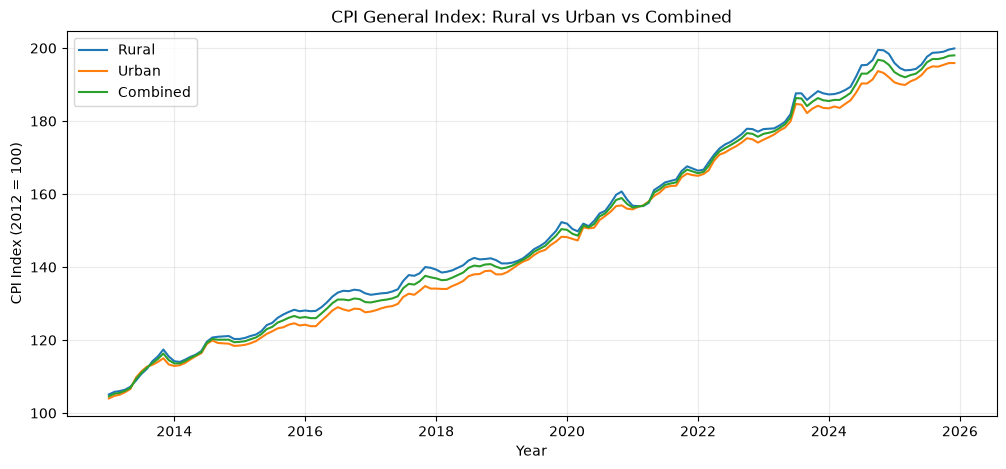

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(general["Date"], general["Rural Index"], label="Rural")
plt.plot(general["Date"], general["Urban Index"], label="Urban")
plt.plot(general["Date"], general["Combined Index"], label="Combined")
plt.title("CPI General Index: Rural vs Urban vs Combined")
plt.xlabel("Year")
plt.ylabel("CPI Index (2012 = 100)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


### Long-term change

This calculates how much the **General CPI index increased from the beginning to the end of the dataset**.

It shows the overall change in prices during the full period. This is **different from the inflation rate in December 2025**, which only shows the price change compared with December 2024.

In [13]:
first = general.iloc[0]
last = general.iloc[-1]

long_term = pd.DataFrame({
    "Measure": ["Rural", "Urban", "Combined"],
    "First Index": [first["Rural Index"], first["Urban Index"], first["Combined Index"]],
    "Last Index": [last["Rural Index"], last["Urban Index"], last["Combined Index"]]
})
long_term["Increase (%)"] = (
    (long_term["Last Index"] / long_term["First Index"] - 1) * 100
).round(2)

display(long_term)


,Measure,First Index,Last Index,Increase (%)
0,Rural,105.10,199.90,90.20
1,Urban,104.00,195.90,88.37
2,Combined,104.60,198.00,89.29


## 5. Inflation trend and extreme months

Here, we look at how inflation changed over time and identify the months when it was unusually high or low.

This helps us answer some important questions:

- **When did inflation reach its highest levels?**
- **Were rural and urban areas affected differently?**
- **Did inflation ever become negative, meaning prices fell compared with the previous year?**
- **Were the recent inflation rates higher or lower than usual?**

Looking at these changes helps us find important periods and possible stories in the CPI data.

In [14]:
# Rural-urban inflation spread
general["Rural-Urban Inflation Gap"] = (
    general["Rural Inflation"] - general["Urban Inflation"]
).round(2)

print("Top 10 months by Combined inflation:")
display(
    general.nlargest(10, "Combined Inflation")[
        ["Date", "Combined Inflation", "Rural Inflation", "Urban Inflation"]
    ].sort_values("Combined Inflation", ascending=False)
)

print("\nBottom 10 months by Combined inflation:")
display(
    general.nsmallest(10, "Combined Inflation")[
        ["Date", "Combined Inflation", "Rural Inflation", "Urban Inflation"]
    ].sort_values("Combined Inflation")
)


Top 10 months by Combined inflation:


,Date,Combined Inflation,Rural Inflation,Urban Inflation
335,2014-01-01,8.60,8.66,8.56
419,2014-04-01,8.48,8.46,8.51
447,2014-05-01,8.33,8.21,8.44
391,2014-03-01,8.25,8.11,8.29
363,2014-02-01,7.88,7.75,8.02
3107,2022-04-01,7.79,8.38,7.09
2603,2020-10-01,7.61,7.75,7.33
2351,2020-01-01,7.59,7.73,7.39
3527,2023-07-01,7.44,7.63,7.20
3247,2022-09-01,7.41,7.56,7.27



Bottom 10 months by Combined inflation:


,Date,Combined Inflation,Rural Inflation,Urban Inflation
4283,2025-10-01,0.25,-0.25,0.88
4311,2025-11-01,0.71,0.10,1.40
4339,2025-12-01,1.33,0.76,2.03
4255,2025-09-01,1.44,1.07,1.83
1483,2017-06-01,1.46,1.52,1.41
4199,2025-07-01,1.61,1.18,2.10
2015,2019-01-01,1.97,1.22,2.91
4227,2025-08-01,2.07,1.69,2.47
4171,2025-06-01,2.10,1.72,2.56
1987,2018-12-01,2.11,1.50,2.91


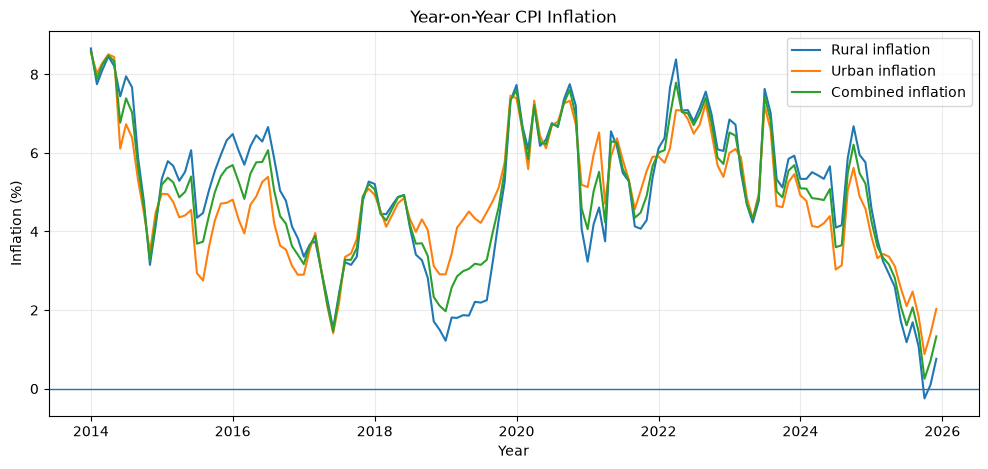

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(general["Date"], general["Rural Inflation"], label="Rural inflation")
plt.plot(general["Date"], general["Urban Inflation"], label="Urban inflation")
plt.plot(general["Date"], general["Combined Inflation"], label="Combined inflation")
plt.axhline(0, linewidth=1)
plt.title("Year-on-Year CPI Inflation")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 6. Rural vs urban divergence

Here, we compare **rural and urban inflation** to see whether prices changed differently in the two areas.

We calculate the **gap between rural and urban inflation** for each month.

A **positive gap** means rural inflation was higher than urban inflation.

A **negative gap** means urban inflation was higher than rural inflation.

This helps us understand whether rural and urban households experienced different levels of price pressure.

In [16]:
spread_summary = pd.DataFrame({
    "Metric": [
        "Average rural-urban inflation gap",
        "Largest rural lead",
        "Largest urban lead",
        "Months rural inflation > urban inflation",
        "Months urban inflation > rural inflation"
    ],
    "Value": [
        general["Rural-Urban Inflation Gap"].mean(),
        general["Rural-Urban Inflation Gap"].max(),
        general["Rural-Urban Inflation Gap"].min(),
        (general["Rural-Urban Inflation Gap"] > 0).sum(),
        (general["Rural-Urban Inflation Gap"] < 0).sum()
    ]
})
display(spread_summary)

print("Months with the widest rural-urban inflation gaps:")
display(
    general.reindex(
        general["Rural-Urban Inflation Gap"].abs().sort_values(ascending=False).index
    ).head(10)[[
        "Date", "Rural Inflation", "Urban Inflation", "Rural-Urban Inflation Gap"
    ]]
)


,Metric,Value
0,Average rural-urban inflation gap,0.11
1,Largest rural lead,1.75
2,Largest urban lead,-2.65
3,Months rural inflation > urban inflation,83.00
4,Months urban inflation > rural inflation,60.00


Months with the widest rural-urban inflation gaps:


,Date,Rural Inflation,Urban Inflation,Rural-Urban Inflation Gap
2127,2019-05-01,1.86,4.51,-2.65
2099,2019-04-01,1.87,4.30,-2.43
2071,2019-03-01,1.80,4.10,-2.30
2211,2019-08-01,2.25,4.49,-2.24
2155,2019-06-01,2.21,4.33,-2.12
2183,2019-07-01,2.19,4.22,-2.03
2743,2021-03-01,4.61,6.52,-1.91
2687,2021-01-01,3.23,5.13,-1.90
2715,2021-02-01,4.19,5.96,-1.77
1063,2016-03-01,5.70,3.95,1.75


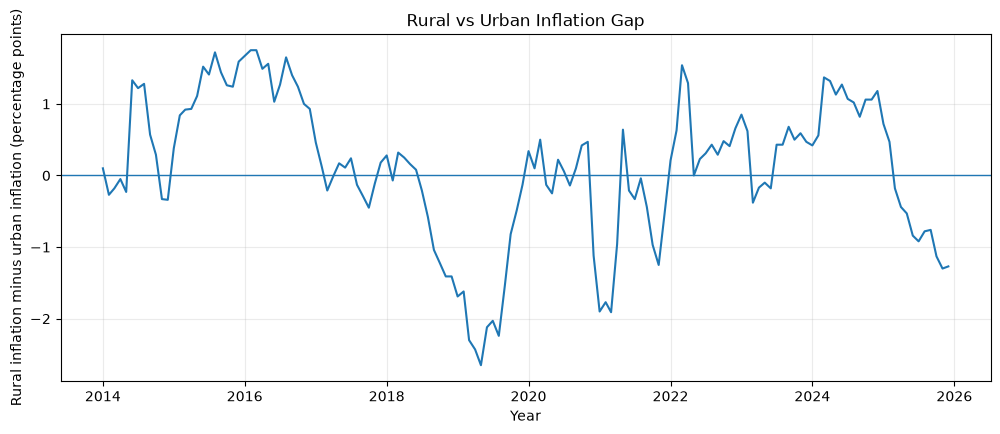

In [17]:
plt.figure(figsize=(12, 4.5))
plt.plot(general["Date"], general["Rural-Urban Inflation Gap"])
plt.axhline(0, linewidth=1)
plt.title("Rural vs Urban Inflation Gap")
plt.xlabel("Year")
plt.ylabel("Rural inflation minus urban inflation (percentage points)")
plt.grid(alpha=0.25)
plt.show()


## 7. Annual inflation

Monthly inflation can change a lot. Annual averages show the overall inflation trend more clearly.

This section calculates the average CPI inflation for rural, urban and combined CPI by year.

,Rural Inflation,Urban Inflation,Combined Inflation
Year,,,
2016,5.62,4.23,4.96
2017,3.32,3.31,3.33
2018,3.78,4.19,3.96
2019,2.94,4.62,3.71
2020,6.67,6.62,6.63
2021,4.76,5.57,5.14
2022,6.94,6.40,6.70
2023,5.80,5.49,5.66
2024,5.43,4.40,4.95


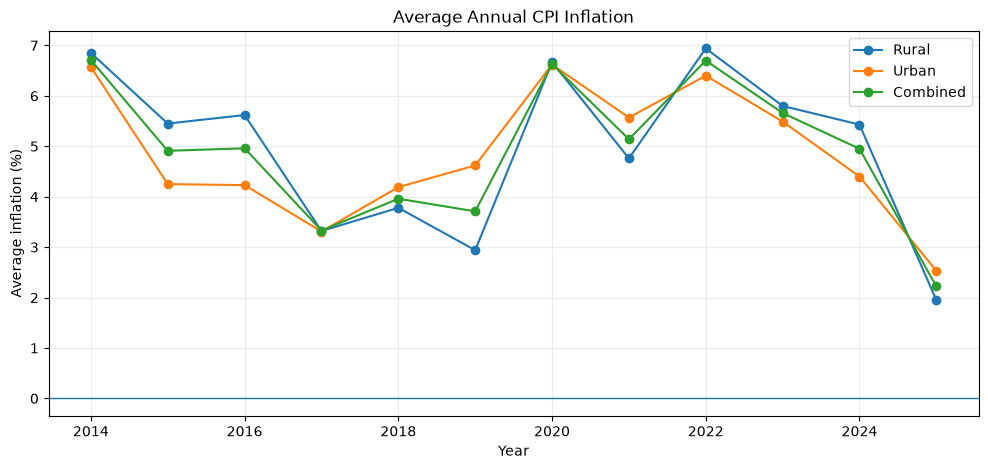

In [25]:
general["Year"] = general["Date"].dt.year

annual = (
    general.groupby("Year")[[
        "Rural Inflation", "Urban Inflation", "Combined Inflation"
    ]]
    .mean()
    .round(2)
)

display(annual.tail(10))

plt.figure(figsize=(12, 5))
plt.plot(annual.index, annual["Rural Inflation"], marker="o", label="Rural")
plt.plot(annual.index, annual["Urban Inflation"], marker="o", label="Urban")
plt.plot(annual.index, annual["Combined Inflation"], marker="o", label="Combined")
plt.axhline(0, linewidth=1)
plt.title("Average Annual CPI Inflation")
plt.xlabel("Year")
plt.ylabel("Average inflation (%)")
plt.legend()
plt.grid(alpha=0.25)

plt.savefig("annual_cpi_inflation.png", dpi=300, bbox_inches="tight")

plt.show()


## 8. Inflation volatility

Two years can have the same average inflation but different levels of price changes.

This section uses the **standard deviation of monthly inflation** to measure how much inflation varied during each year.

In [18]:
volatility = (
    general.groupby("Year")[[
        "Rural Inflation", "Urban Inflation", "Combined Inflation"
    ]]
    .std()
    .round(2)
    .sort_values("Combined Inflation", ascending=False)
)

display(volatility.head(10))


,Rural Inflation,Urban Inflation,Combined Inflation
Year,,,
2014,1.87,1.82,1.83
2019,1.81,1.15,1.49
2025,1.49,0.91,1.23
2017,1.02,1.09,1.06
2023,1.06,0.88,0.97
2018,1.25,0.63,0.97
2016,0.95,0.81,0.88
2020,0.99,0.70,0.84
2021,1.01,0.62,0.76


## 9. Food vs non-food analysis

The workbook has inflation data for different groups such as food, clothing, housing, fuel and miscellaneous items.

Since there are no expenditure weights, we will **compare their inflation rates directly** instead of calculating their contribution to overall inflation.

In [19]:
broad_groups = [
    "A.1) Food and beverages",
    "A.2) Pan, tobacco and intoxicants",
    "A.3) Clothing and footwear",
    "A.4) Housing",
    "A.5) Fuel and light",
    "A.6) Miscellaneous"
]

group_data = clean[clean["Commodity"].isin(broad_groups)].copy()

latest_date = group_data["Date"].max()
latest_groups = (
    group_data[group_data["Date"].eq(latest_date)]
    [["Commodity", "Rural Inflation", "Urban Inflation", "Combined Inflation"]]
    .sort_values("Combined Inflation", ascending=False)
)

print("Broad-group inflation in", latest_date.strftime("%B %Y"))
display(latest_groups)


Broad-group inflation in December 2025


,Commodity,Rural Inflation,Urban Inflation,Combined Inflation
4359,A.6) Miscellaneous,6.60,5.60,6.17
4353,"A.2) Pan, tobacco and intoxicants",2.68,3.63,2.96
4357,A.4) Housing,NaN,2.86,2.86
4358,A.5) Fuel and light,1.54,2.76,1.97
4354,A.3) Clothing and footwear,1.25,1.70,1.44
4340,A.1) Food and beverages,-2.31,-1.05,-1.85


In [20]:
# Average combined inflation by broad group across the available period
group_avg = (
    group_data.groupby("Commodity")["Combined Inflation"]
    .agg(["mean", "std", "min", "max"])
    .round(2)
    .sort_values("mean", ascending=False)
)

group_avg.columns = ["Average Inflation", "Volatility (SD)", "Minimum", "Maximum"]
display(group_avg)


,Average Inflation,Volatility (SD),Minimum,Maximum
Commodity,,,,
"A.2) Pan, tobacco and intoxicants",5.72,2.74,1.15,11.28
A.6) Miscellaneous,5.05,1.20,2.89,8.03
A.3) Clothing and footwear,4.99,2.39,0.96,10.17
A.1) Food and beverages,4.91,3.27,-3.72,12.16
A.4) Housing,4.84,2.05,2.56,13.73
A.5) Fuel and light,4.38,4.10,-5.48,14.35


## 10. Persistent inflation by category

This section looks at which categories have **consistently high inflation** over the period.

We compare:
- **Average inflation** – how fast prices rise on average
- **Volatility** – how much inflation changes
- **Recent inflation** – how current inflation compares with the past

This helps avoid treating one unusually high month as a long-term trend.

In [21]:
# Compare each broad group with its latest observation
group_latest = (
    group_data[group_data["Date"].eq(latest_date)]
    .set_index("Commodity")["Combined Inflation"]
)

group_analysis = group_avg.copy()
group_analysis["Latest Inflation"] = group_latest
group_analysis["Latest minus Historical Avg"] = (
    group_analysis["Latest Inflation"] - group_analysis["Average Inflation"]
).round(2)

display(group_analysis.sort_values("Latest minus Historical Avg", ascending=False))


,Average Inflation,Volatility (SD),Minimum,Maximum,Latest Inflation,Latest minus Historical Avg
Commodity,,,,,,
A.6) Miscellaneous,5.05,1.20,2.89,8.03,6.17,1.12
A.4) Housing,4.84,2.05,2.56,13.73,2.86,-1.98
A.5) Fuel and light,4.38,4.10,-5.48,14.35,1.97,-2.41
"A.2) Pan, tobacco and intoxicants",5.72,2.74,1.15,11.28,2.96,-2.76
A.3) Clothing and footwear,4.99,2.39,0.96,10.17,1.44,-3.55
A.1) Food and beverages,4.91,3.27,-3.72,12.16,-1.85,-6.76


## 11. Individual commodities

Broad groups can hide different price movements.

This section identifies the commodities with the **highest and lowest inflation** in the latest month.

A single month is only a snapshot and does not show a long-term trend.

In [22]:
latest = clean[clean["Date"].eq(latest_date)].copy()

latest_rank = latest[
    ["Commodity", "Combined Index", "Combined Inflation",
     "Rural Inflation", "Urban Inflation"]
].sort_values("Combined Inflation", ascending=False)

print("Highest inflation categories — latest month:")
display(latest_rank.head(10))

print("Lowest inflation categories — latest month:")
display(latest_rank.tail(10).sort_values("Combined Inflation"))


Highest inflation categories — latest month:


,Commodity,Combined Index,Combined Inflation,Rural Inflation,Urban Inflation
4365,A.6.6) Personal Care and Effects,265.10,28.07,28.50,27.45
4348,A.1.5) Oils and fats,196.10,6.75,7.20,5.84
4349,A.1.6) Fruits,203.30,6.66,7.62,5.61
4359,A.6) Miscellaneous,198.00,6.17,6.60,5.60
4345,A.1.2) Meat and fish,233.90,5.12,4.84,5.68
4346,A.1.3) Egg,222.20,4.76,5.10,4.22
4352,A.1.9) Sugar and confectionery,137.00,4.66,5.00,3.99
4344,"A.1.12) Prepared meals, snacks, sweets etc.",213.30,3.49,3.28,3.78
4361,A.6.2) Health,204.80,3.43,3.40,3.50
4364,A.6.5) Education,196.00,3.32,2.91,3.67


Lowest inflation categories — latest month:


,Commodity,Combined Index,Combined Inflation,Rural Inflation,Urban Inflation
4350,A.1.7) Vegetables,210.60,-18.47,-19.68,-16.42
4351,A.1.8) Pulses and products,181.80,-15.09,-15.16,-15.00
4366,B) Consumer Food Price Index,201.10,-2.71,-3.08,-2.09
4342,A.1.10) Spices,222.50,-2.15,-2.40,-1.65
4340,A.1) Food and beverages,202.10,-1.85,-2.31,-1.05
4356,A.3.2) Footwear,185.40,-0.43,-0.36,-0.51
4341,A.1.1) Cereals and products,197.40,-0.35,-0.85,0.61
4362,A.6.3) Transport and communication,172.30,0.76,1.02,0.60
4363,A.6.4) Recreation and amusement,180.90,1.17,0.99,1.30
4339,A) General Index,198.00,1.33,0.76,2.03


## 12. Recent vs historical inflation

This section compares:
- **Latest year**
- **Previous year**
- **Full-period average**

This helps show whether recent inflation is **higher or lower than the historical average**.

In [23]:
latest_year = general["Year"].max()
previous_year = latest_year - 1

comparison = pd.DataFrame({
    "Measure": ["Rural", "Urban", "Combined"],
    "Full-period average": [
        general["Rural Inflation"].mean(),
        general["Urban Inflation"].mean(),
        general["Combined Inflation"].mean()
    ],
    f"{previous_year} average": [
        general.loc[general["Year"].eq(previous_year), "Rural Inflation"].mean(),
        general.loc[general["Year"].eq(previous_year), "Urban Inflation"].mean(),
        general.loc[general["Year"].eq(previous_year), "Combined Inflation"].mean()
    ],
    f"{latest_year} average": [
        general.loc[general["Year"].eq(latest_year), "Rural Inflation"].mean(),
        general.loc[general["Year"].eq(latest_year), "Urban Inflation"].mean(),
        general.loc[general["Year"].eq(latest_year), "Combined Inflation"].mean()
    ]
}).round(2)

display(comparison)


,Measure,Full-period average,2024 average,2025 average
0,Rural,4.96,5.43,1.95
1,Urban,4.85,4.40,2.53
2,Combined,4.91,4.95,2.22


## 14. Relationships between categories

Correlation does **not** prove causation, but it can show whether categories tend to move together.

This section calculates the **correlation between broad-group inflation rates** to identify categories that often rise or fall together.

In [24]:
pivot = group_data.pivot_table(
    index="Date",
    columns="Commodity",
    values="Combined Inflation"
)

corr = pivot.corr().round(2)

display(corr)


Commodity,A.1) Food and beverages,"A.2) Pan, tobacco and intoxicants",A.3) Clothing and footwear,A.4) Housing,A.5) Fuel and light,A.6) Miscellaneous
Commodity,,,,,,
A.1) Food and beverages,1.00,0.06,0.23,0.03,-0.13,-0.01
"A.2) Pan, tobacco and intoxicants",0.06,1.00,0.03,0.37,0.06,-0.05
A.3) Clothing and footwear,0.23,0.03,1.00,0.36,0.71,0.31
A.4) Housing,0.03,0.37,0.36,1.00,0.26,0.03
A.5) Fuel and light,-0.13,0.06,0.71,0.26,1.00,0.48
A.6) Miscellaneous,-0.01,-0.05,0.31,0.03,0.48,1.00


**Story idea:**

India's inflation hit its lowest point in a decade, driven largely by a collapse in food and beverage prices. Annual Combined CPI inflation fell to 2.22% in 2025 — the lowest annual average in the past ten years (2016–2025) — extending a three-year decline from 6.70% in 2022 to 5.66% in 2023 to 4.95% in 2024. Rural inflation averaged 1.95% and urban 2.53% in 2025, both falling sharply from 5.43% and 4.40% respectively the year before.

Food and beverages was the only major CPI category in negative territory in December 2025, at -1.85%, a full 6.76 percentage points below its own historical average — the largest such gap of any broad group in the dataset. The drag came overwhelmingly from a handful of staples: vegetables fell 18.47% year-on-year and pulses fell 15.09%. Every other broad category stayed positive over the same period: housing at 2.86%, fuel and light at 1.97%, miscellaneous goods at 6.17%, and personal care and effects up just over 28%.

Despite the low annual average, monthly inflation in 2025 was more volatile than in most other years in the dataset (standard deviation of 1.23, the third-highest of any year after 2014 and 2019). That volatility sat alongside the sharp swings in vegetable and pulse prices, suggesting the year's price story was less a broad, gradual cooling and more a sharp, food-driven correction — though isolating food-category volatility specifically (rather than volatility in the headline number) would sharpen that point further.

Historical comparison: inflation reached 8.60% in January 2014 and stayed elevated at 6.63% in 2020 and 6.70% in 2022, dipping to 5.14% in 2021 in between — underscoring that 2025's low is a departure from a decade that, until now, hadn't dipped meaningfully below 3%.
